# Tier 9 coupled sizing, mission optimization and energy allocation

One explicit `asb.Opti` (`examples/coupled_sizing.py`) sizes the aircraft and
optimizes its mission at the same time:

| Group | Contents |
|---|---|
| Design variables | MTOM, fuel load, wing position and area, both tail areas, motor and generator peak torques (McDonald rubber machines), turboshaft rating, battery power **and energy**, rotor disk area |
| Mission variables | cruise speed; electric power fraction of every segment (energy allocation); per-point angle of attack, rotor speed, battery current, generator torque |
| Constraints | mass closure (structural condition fed by the solved cruise L/D); hover pitch trim; Tier 7 requirements at MTOM; Tier 8 reference mission with 10 % fuel reserve and SOC >= 0.30; engine-out reserve (60 s battery-only hover from SOC 0.30 to >= 0.10); static margin >= 10 %; Cn_beta >= 0.06 /rad; failed-rotor rudder <= 20 deg; every operating margin >= 0 |
| Objective | minimum MTOM (reference) or minimum mission fuel (trade case) |

No sub-loop, fixed-point iteration or second solver exists: every discipline
contributes equations to the same problem. Two numerical details make the large
problem well conditioned: flight-point equalities are normalized (lift by
weight, bus powers by installed motor power), and the battery mass, sized in
both energy and power, uses an optional smooth maximum (overestimate at most
2 kg x ln 2).

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier9_coupled_sizing
```

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox.numpy as np
import matplotlib.pyplot as plt

from aircraft_closure.mission.mission import Mission
from aircraft_closure.mission.segments import CruiseSegment
from aircraft_closure.powertrain.components.battery import Battery
from examples.coupled_sizing import soc_emergency_floor, solve_coupled_sizing
from examples.mission_analysis import fuel_factor, reference_mission, soc_minimum

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Smooth battery mass

`Battery.get_mass` keeps the exact maximum of energy- and power-sized mass by
default (Tier 1 identities unchanged). With `mass_smoothing_kg` set, it uses
AeroSandbox's softmax, which is never below the exact value and at most
smoothing x ln 2 above it. Without it, the coupled optimum sits on the kink and
IPOPT stalls.

In [2]:
powers_W = np.linspace(2e4, 3e5, 60)
exact = np.array([Battery(max_discharge_power_W=p).get_mass() for p in powers_W])
smooth = np.array([float(Battery(max_discharge_power_W=p, mass_smoothing_kg=2.0).get_mass()) for p in powers_W])
check("battery: smooth mass never below the exact maximum", np.all(smooth >= exact - 1e-12))
check("battery: smooth mass within 2 kg x ln 2 of the exact maximum", np.all(smooth - exact <= 2 * np.log(2) + 1e-12))
check("battery: default stays the exact maximum", Battery().get_mass() == max(36e6 / 9e5, 1e5 / 3000))

PASS  battery: smooth mass never below the exact maximum
PASS  battery: smooth mass within 2 kg x ln 2 of the exact maximum
PASS  battery: default stays the exact maximum


## 2. Reference case: minimum take-off mass

The optimizer resizes everything at once. The margin report names what binds:
the max-speed requirement sizes the turbogenerator, hover sizes motors, gearboxes
and rotors, the engine-out reserve sizes the battery (both power and energy),
static margin and $C_{n\beta}$ size the tails, and the mission's SOC floor binds
because the optimizer spends the battery it must carry anyway.

In [3]:
light = solve_coupled_sizing("mass_takeoff")
print(f"MTOM {light.mass_takeoff_kg:.1f} kg, empty {light.mass_empty_kg:.1f} kg, fuel {light.mass_fuel_kg:.2f} kg, "
      f"battery {light.energy_battery_kWh:.1f} kWh / {light.power_max_discharge_battery_W / 1e3:.0f} kW")
print(f"wing {light.area_wing_m2:.2f} m2, tails {light.area_horizontal_tail_m2:.2f} / {light.area_vertical_tail_m2:.2f} m2, "
      f"disk {light.area_disk_m2:.2f} m2 per rotor")
print(f"motor {light.power_rated_motor_W / 1e3:.1f} kW, generator {light.power_rated_generator_W / 1e3:.1f} kW, "
      f"turboshaft {light.power_rated_turboshaft_W / 1e3:.1f} kW; cruise {light.velocity_cruise_m_s:.1f} m/s, L/D {light.lift_to_drag_cruise:.2f}")
print("binding:", ", ".join(light.binding))
check("closure: residual below 1e-5 kg", abs(light.closure_residual_kg) < 1e-5)
check("closure: masses sum to MTOM", close(sum(m for _, m in light.component_masses_kg), light.mass_takeoff_kg, rel=1e-8))
check("constraints: every margin non-negative", light.min_margin > -1e-6)
check("constraints: fuel load = 1.1 x mission fuel", close(light.mass_fuel_kg, fuel_factor * light.mass_fuel_burnt_kg, rel=1e-7))
check("constraints: landing SOC at the floor", close(light.soc_end, soc_minimum, rel=1e-6))
check("constraints: static margin and Cn_beta met", light.static_margin >= 0.1 - 1e-7 and light.cn_beta_per_rad >= 0.06 - 1e-7)
check("constraints: failed-rotor rudder within 20 deg", light.rudder_failed_rotor_deg <= 20 + 1e-6)
for label in ("max_speed: turboshaft power_shaft_W", "hover: motor power_shaft_W", "soc_after_engine_out_hover",
              "engine-out hover: battery discharge_power_W", "static_margin", "cn_beta_per_rad", "soc_end"):
    check(f"binding: {label}", label in light.binding)

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


MTOM 883.6 kg, empty 561.0 kg, fuel 22.65 kg, battery 13.5 kWh / 161 kW
wing 5.05 m2, tails 1.24 / 1.09 m2, disk 4.62 m2 per rotor
motor 46.8 kW, generator 175.3 kW, turboshaft 175.3 kW; cruise 45.3 m/s, L/D 8.13
binding: max_speed: turboshaft power_shaft_W, max_speed: generator power_shaft_W, engine-out hover: battery discharge_power_W, hover: motor power_shaft_W, hover: gearbox power_input_W, hover: propulsor power_shaft_W, soc_after_engine_out_hover, static_margin, cn_beta_per_rad, soc_end
PASS  closure: residual below 1e-5 kg
PASS  closure: masses sum to MTOM
PASS  constraints: every margin non-negative
PASS  constraints: fuel load = 1.1 x mission fuel
PASS  constraints: landing SOC at the floor
PASS  constraints: static margin and Cn_beta met
PASS  constraints: failed-rotor rudder within 20 deg
PASS  binding: max_speed: turboshaft power_shaft_W
PASS  binding: hover: motor power_shaft_W
PASS  binding: soc_after_engine_out_hover
PASS  binding: engine-out hover: battery discharge_pow

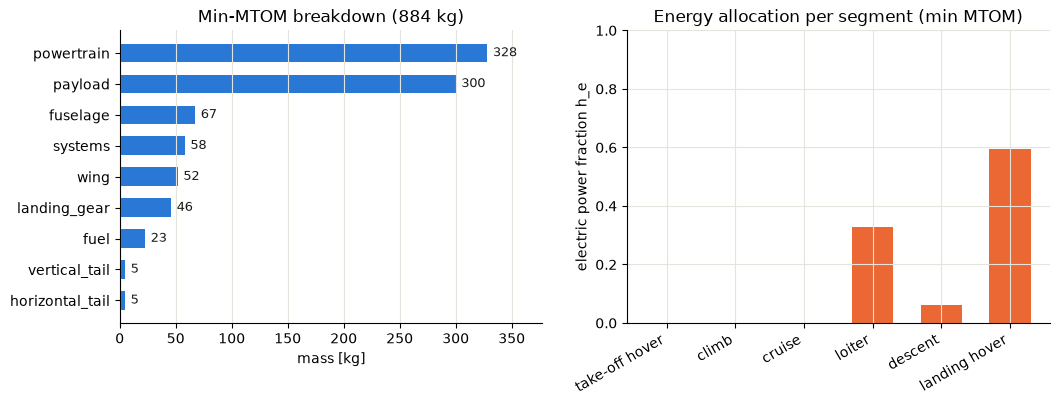

PASS  allocation: every h_e within [0, 1]
PASS  allocation: the carried battery is used during the mission


In [4]:
items = sorted(((n, m) for n, m in light.component_masses_kg if m > 0), key=lambda x: x[1])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
ax1.barh([n for n, _ in items], [m for _, m in items], color=blue, height=0.6)
for y, (_, m) in enumerate(items):
    ax1.text(m + 5, y, f"{m:.0f}", va="center", fontsize=9, color=ink)
ax1.set(xlabel="mass [kg]", xlim=(0, max(m for _, m in items) * 1.15), title=f"Min-MTOM breakdown ({light.mass_takeoff_kg:.0f} kg)")
ax1.grid(axis="y", visible=False)
labels = [s[0] for s in light.segments]
ax2.bar(np.arange(len(labels)), [s[5] for s in light.segments], color=orange, width=0.6)
ax2.set_xticks(np.arange(len(labels)), labels, rotation=30, ha="right")
ax2.set(ylabel="electric power fraction h_e", ylim=(0, 1), title="Energy allocation per segment (min MTOM)")
plt.show()
check("allocation: every h_e within [0, 1]", all(-1e-9 <= s[5] <= 1 + 1e-9 for s in light.segments))
check("allocation: the carried battery is used during the mission", sum(s[3] for s in light.segments) > 0)

## 3. Trade case: minimum fuel

Same constraints, objective mission fuel. The optimizer flies almost entirely on
the battery, which then sizes far larger and drags MTOM, wing and rotors up
with it: the classic mass-versus-energy trade of a hybrid, now produced by one
problem rather than by an outer sweep.

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


CasADi - 2026-10-02 14:54:59 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 122, col 0).") [.../casadi/core/oracle_function.cpp:408]


                          min MTOM    min fuel
MTOM [kg]                   883.62     2122.62
fuel load [kg]               22.65        1.28
battery [kWh]                13.54      183.73
wing [m2]                     5.05       20.50
disk per rotor [m2]           4.62       10.82
turboshaft [kW]             175.35      251.85
cruise speed [m/s]           45.31       59.99
cruise L/D                    8.13       13.12
PASS  trade: min-fuel design burns less fuel
PASS  trade: min-fuel design carries a larger battery
PASS  trade: min-fuel design is heavier
PASS  trade: min-fuel constraints all satisfied


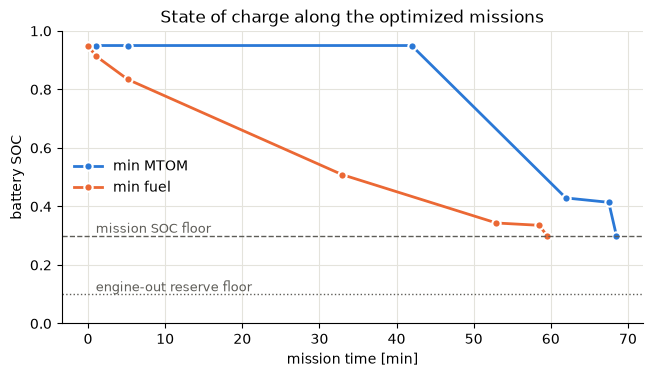

In [5]:
frugal = solve_coupled_sizing("fuel")
rows = [("MTOM [kg]", light.mass_takeoff_kg, frugal.mass_takeoff_kg),
        ("fuel load [kg]", light.mass_fuel_kg, frugal.mass_fuel_kg),
        ("battery [kWh]", light.energy_battery_kWh, frugal.energy_battery_kWh),
        ("wing [m2]", light.area_wing_m2, frugal.area_wing_m2),
        ("disk per rotor [m2]", light.area_disk_m2, frugal.area_disk_m2),
        ("turboshaft [kW]", light.power_rated_turboshaft_W / 1e3, frugal.power_rated_turboshaft_W / 1e3),
        ("cruise speed [m/s]", light.velocity_cruise_m_s, frugal.velocity_cruise_m_s),
        ("cruise L/D", light.lift_to_drag_cruise, frugal.lift_to_drag_cruise)]
print(f"{'':<22}{'min MTOM':>12}{'min fuel':>12}")
for name, a, b in rows:
    print(f"{name:<22}{a:12.2f}{b:12.2f}")
check("trade: min-fuel design burns less fuel", frugal.mass_fuel_kg < light.mass_fuel_kg)
check("trade: min-fuel design carries a larger battery", frugal.energy_battery_kWh > light.energy_battery_kWh)
check("trade: min-fuel design is heavier", frugal.mass_takeoff_kg > light.mass_takeoff_kg)
check("trade: min-fuel constraints all satisfied", frugal.min_margin > -1e-6 and abs(frugal.closure_residual_kg) < 1e-5)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for result, label, color in ((light, "min MTOM", blue), (frugal, "min fuel", orange)):
    t, soc = [0.0], [0.95]
    for s in result.segments:
        t.append(t[-1] + s[1] / 60)
        soc.append(s[4])
    ax.plot(t, soc, color=color, lw=2, marker="o", ms=6, mec="white", mew=1.5, label=label)
ax.axhline(soc_minimum, color=ink_muted, lw=1, ls="--")
ax.axhline(soc_emergency_floor, color=ink_muted, lw=1, ls=":")
ax.text(1, soc_minimum + 0.01, "mission SOC floor", color=ink_muted, fontsize=9)
ax.text(1, soc_emergency_floor + 0.01, "engine-out reserve floor", color=ink_muted, fontsize=9)
ax.set(xlabel="mission time [min]", ylabel="battery SOC", ylim=(0, 1), title="State of charge along the optimized missions")
ax.legend(frameon=False, loc="center left")
plt.show()

## 4. Mission-driven growth: cruise distance

Re-solving the whole coupled problem for 50, 100 and 150 km of cruise shows the
design responding to the mission: fuel and MTOM grow with distance.

In [6]:
def mission_with_cruise(distance_m):
    base = reference_mission(hybridization_hover=None, hybridization_other=None, velocity_cruise_m_s=None)
    return Mission(tuple(replace(s, distance_m=distance_m) if isinstance(s, CruiseSegment) else s for s in base.segments))


distances_km = [50, 100, 150]
sweep = [solve_coupled_sizing("mass_takeoff", mission=mission_with_cruise(d * 1000.0)) for d in distances_km]
for d, r in zip(distances_km, sweep):
    print(f"{d:4d} km: MTOM {r.mass_takeoff_kg:7.1f} kg, fuel {r.mass_fuel_kg:6.2f} kg, battery {r.energy_battery_kWh:5.1f} kWh, "
          f"cruise {r.velocity_cruise_m_s:.1f} m/s")
check("sweep: fuel grows with cruise distance", np.all(np.diff([r.mass_fuel_kg for r in sweep]) > 0))
check("sweep: MTOM grows with cruise distance", np.all(np.diff([r.mass_takeoff_kg for r in sweep]) > 0))
check("sweep: 100 km case reproduces the reference", close(sweep[1].mass_takeoff_kg, light.mass_takeoff_kg, rel=1e-5))

  50 km: MTOM   873.1 kg, fuel  16.04 kg, battery  13.4 kWh, cruise 45.2 m/s
 100 km: MTOM   883.6 kg, fuel  22.65 kg, battery  13.5 kWh, cruise 45.3 m/s
 150 km: MTOM   894.4 kg, fuel  29.38 kg, battery  13.7 kWh, cruise 45.5 m/s
PASS  sweep: fuel grows with cruise distance
PASS  sweep: MTOM grows with cruise distance
PASS  sweep: 100 km case reproduces the reference


## 5. What this tier does and does not claim

The coupled problem is a consistent conceptual-design formulation, not a
prediction of any real aircraft. Several results follow directly from stated
simplifications and should be read that way: the small min-MTOM wing (no
landing-field or gust requirement, stall-limited only by the slowest segment);
constant turboshaft efficiency (no lapse or part-power penalty, so the battery
never wins on mass alone); point-mass rotors and symmetric multiplicity. Tier 10
(maps and decks) is where engine part-power and altitude behaviour enter.

## 6. Summary and unit test suite

In [7]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

26 / 26 notebook checks passed


In [8]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 201 tests in 4.682s

OK
